### Consistency of Payment Amounts Over Time

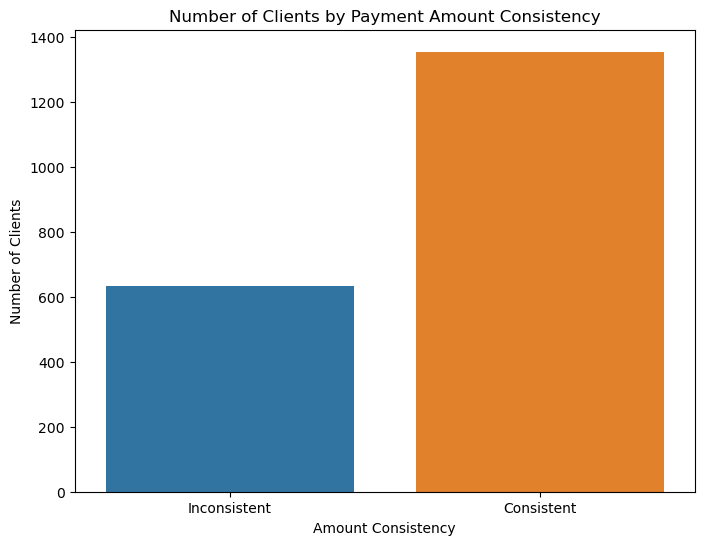

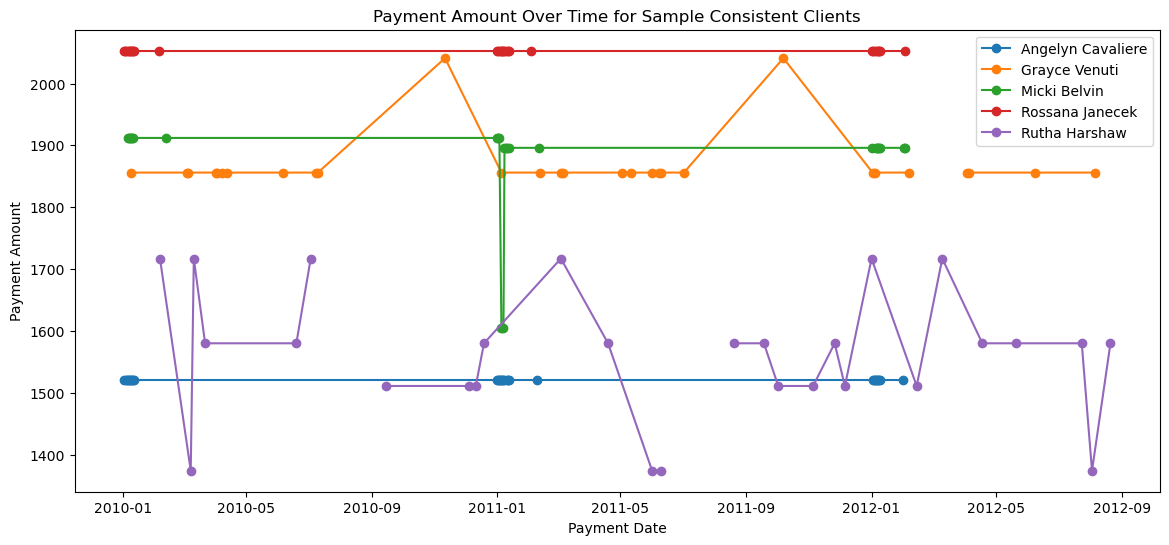

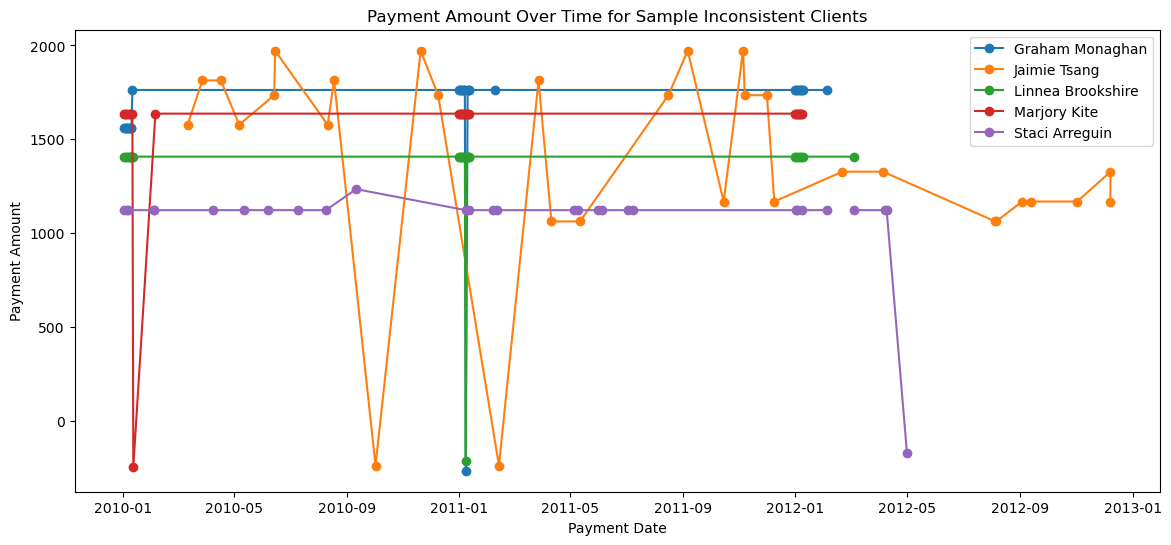

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with error handling
rental_data = pd.read_csv('/Users/grovercastroduenas/Desktop/Machine Learning/Final project/rental_data.csv') 

# Convert relevant columns to datetime
rental_data['paymentDate_clean'] = pd.to_datetime(rental_data['paymentDate_clean'], errors='coerce')
rental_data['dob_clean'] = pd.to_datetime(rental_data['dob_clean'], errors='coerce')

# Calculate mean, standard deviation, and coefficient of variation (CV) for each client
client_stats_amount = rental_data.groupby('name')['paymentAmount_clean'].agg(['mean', 'std'])
client_stats_amount['cv'] = client_stats_amount['std'] / client_stats_amount['mean']

# Define a threshold for CV to classify clients as consistent or not (CV <= 0.1)
cv_threshold = 0.1
client_stats_amount['is_consistent_amount'] = client_stats_amount['cv'] <= cv_threshold

# Plot the number of consistent and inconsistent clients by payment amount consistency
plt.figure(figsize=(8, 6))
sns.countplot(x='is_consistent_amount', data=client_stats_amount)
plt.title('Number of Clients by Payment Amount Consistency')
plt.xlabel('Amount Consistency')
plt.ylabel('Number of Clients')
plt.xticks([0, 1], ['Inconsistent', 'Consistent'])
plt.show()

# Plot the payment amounts over time for a small sample of consistent clients
sample_consistent_clients_amount = client_stats_amount[client_stats_amount['is_consistent_amount']].sample(5, random_state=42).index
sample_data_consistent_amount = rental_data[rental_data['name'].isin(sample_consistent_clients_amount)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_consistent_amount.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Sample Consistent Clients')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()

# Plot the payment amounts over time for a small sample of inconsistent clients
sample_inconsistent_clients_amount = client_stats_amount[~client_stats_amount['is_consistent_amount']].sample(5, random_state=42).index
sample_data_inconsistent_amount = rental_data[rental_data['name'].isin(sample_inconsistent_clients_amount)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_inconsistent_amount.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Sample Inconsistent Clients')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()

### Consistency of Payment Days Over Time

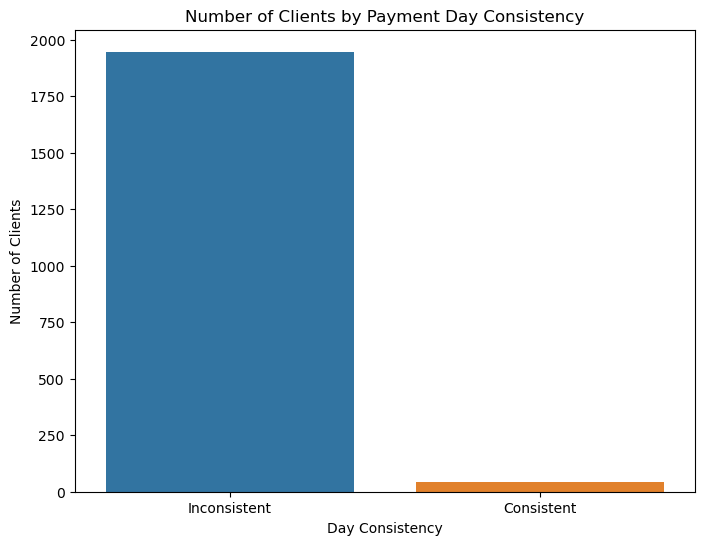

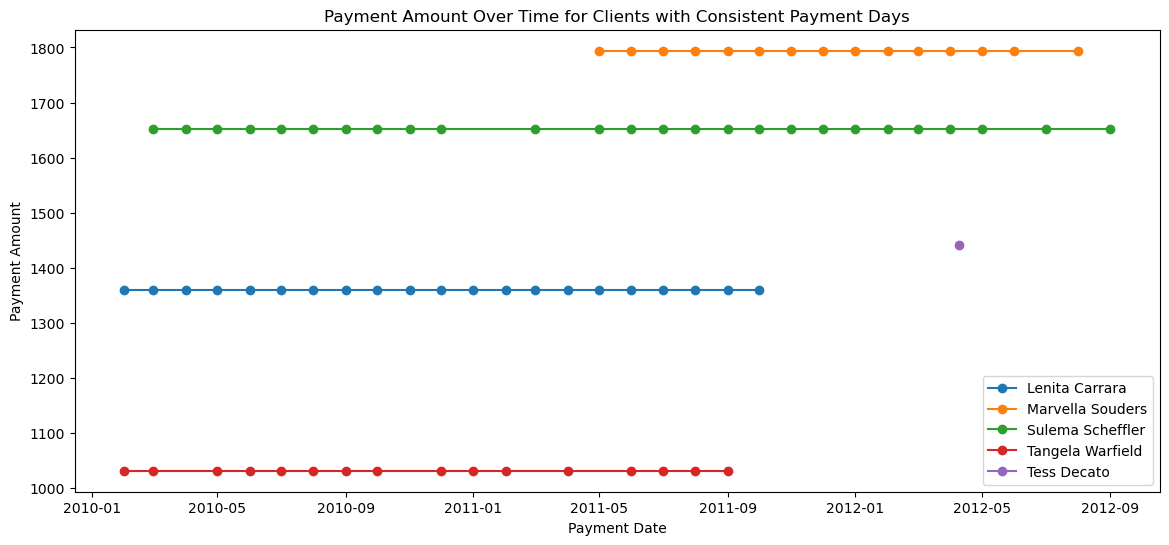

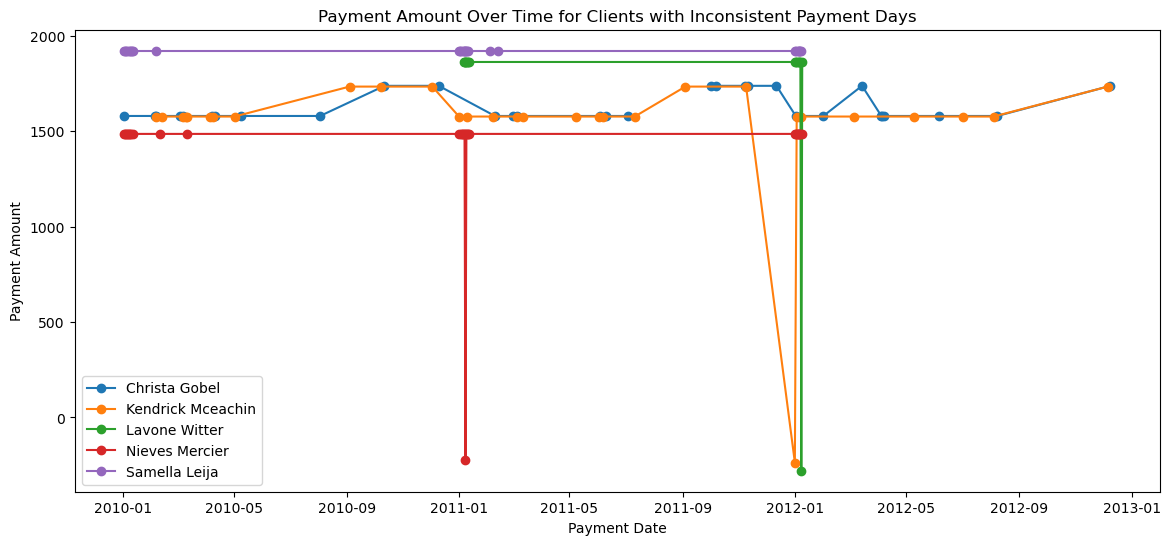

In [7]:
# Convert relevant columns to datetime
rental_data['paymentDate_clean'] = pd.to_datetime(rental_data['paymentDate_clean'], errors='coerce')
rental_data['dob_clean'] = pd.to_datetime(rental_data['dob_clean'], errors='coerce')

# Extract the day of the month from payment dates
rental_data['payment_day'] = rental_data['paymentDate_clean'].dt.day

# Calculate mean, standard deviation, and coefficient of variation (CV) for each client
client_stats_day = rental_data.groupby('name')['payment_day'].agg(['mean', 'std']).fillna(0)
client_stats_day['cv'] = client_stats_day['std'] / client_stats_day['mean']

# Define a threshold for CV to classify clients as consistent or not (CV <= 0.1)
cv_threshold = 0.1
client_stats_day['is_consistent_day'] = client_stats_day['cv'] <= cv_threshold

# Plot the number of consistent and inconsistent clients by payment day consistency
plt.figure(figsize=(8, 6))
sns.countplot(x='is_consistent_day', data=client_stats_day)
plt.title('Number of Clients by Payment Day Consistency')
plt.xlabel('Day Consistency')
plt.ylabel('Number of Clients')
plt.xticks([0, 1], ['Inconsistent', 'Consistent'])
plt.show()

# Combine payment day consistency with the original data
rental_data['day_consistency'] = rental_data['name'].map(client_stats_day['is_consistent_day'])

# Plot the payment amounts over time for a small sample of clients with consistent payment days
sample_consistent_clients_day = client_stats_day[client_stats_day['is_consistent_day']].sample(5, random_state=42).index
sample_data_consistent_day = rental_data[rental_data['name'].isin(sample_consistent_clients_day)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_consistent_day.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Clients with Consistent Payment Days')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()

# Plot the payment amounts over time for a small sample of clients with inconsistent payment days
sample_inconsistent_clients_day = client_stats_day[~client_stats_day['is_consistent_day']].sample(5, random_state=42).index
sample_data_inconsistent_day = rental_data[rental_data['name'].isin(sample_inconsistent_clients_day)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_inconsistent_day.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Clients with Inconsistent Payment Days')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()

### Combined Consistency of Both Payment Amounts and Payment Days



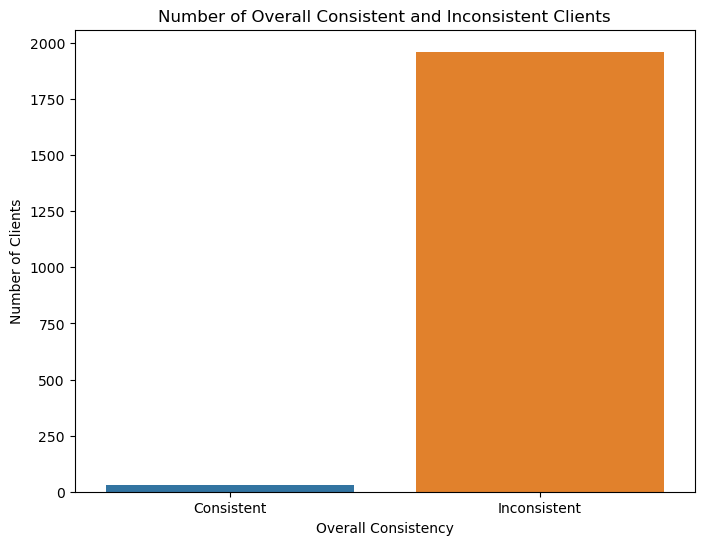

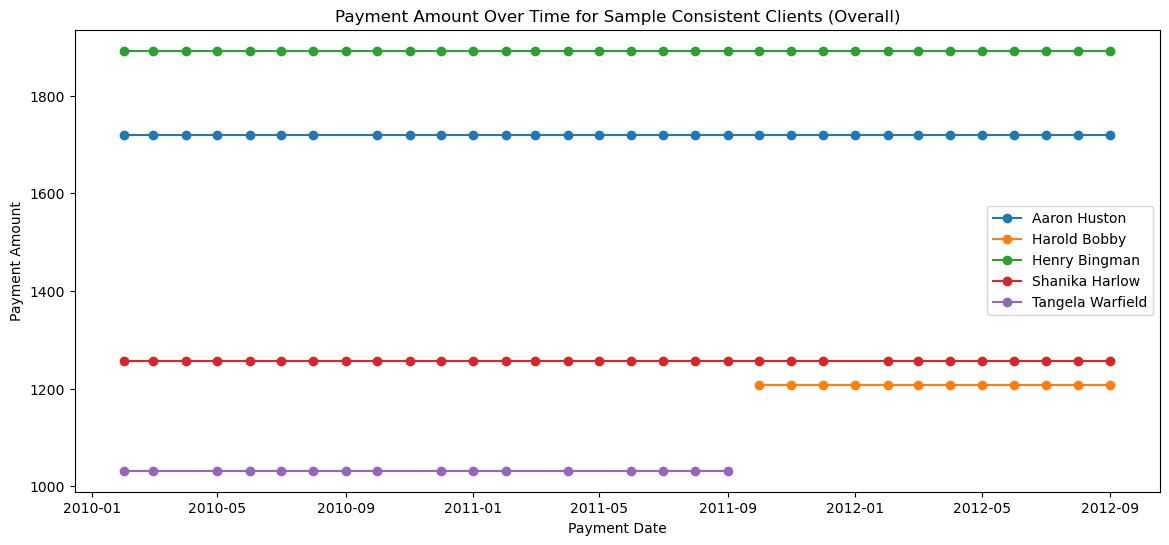

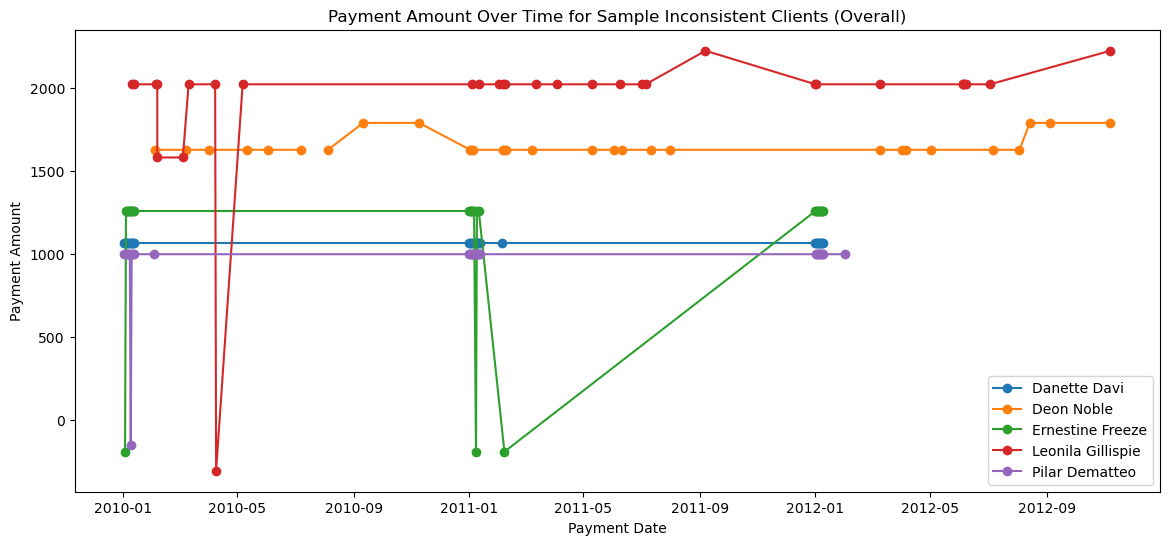

In [8]:
# Combine payment amount consistency with payment day consistency
client_stats_amount['is_consistent_day'] = client_stats_day['is_consistent_day']

# Classify clients based on both amount and day consistency
client_stats_amount['overall_consistency'] = client_stats_amount.apply(
    lambda row: 'Consistent' if row['is_consistent_amount'] and row['is_consistent_day'] else 'Inconsistent', axis=1)

# Plot the number of consistent and inconsistent clients by overall consistency
plt.figure(figsize=(8, 6))
sns.countplot(x='overall_consistency', data=client_stats_amount)
plt.title('Number of Overall Consistent and Inconsistent Clients')
plt.xlabel('Overall Consistency')
plt.ylabel('Number of Clients')
plt.show()

# Plot the payment amounts over time for a small sample of overall consistent clients
sample_consistent_clients_overall = client_stats_amount[client_stats_amount['overall_consistency'] == 'Consistent'].sample(5, random_state=42).index
sample_data_consistent_overall = rental_data[rental_data['name'].isin(sample_consistent_clients_overall)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_consistent_overall.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Sample Consistent Clients (Overall)')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()

# Plot the payment amounts over time for a small sample of overall inconsistent clients
sample_inconsistent_clients_overall = client_stats_amount[client_stats_amount['overall_consistency'] == 'Inconsistent'].sample(5, random_state=42).index
sample_data_inconsistent_overall = rental_data[rental_data['name'].isin(sample_inconsistent_clients_overall)]

plt.figure(figsize=(14, 6))
for name, group in sample_data_inconsistent_overall.groupby('name'):
    plt.plot(group['paymentDate_clean'], group['paymentAmount_clean'], marker='o', linestyle='-', label=name)

plt.title('Payment Amount Over Time for Sample Inconsistent Clients (Overall)')
plt.xlabel('Payment Date')
plt.ylabel('Payment Amount')
plt.legend()
plt.show()




### Initial Exploratory Data Analysis (EDA) including missing values, histograms, and CV distribution


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56610 entries, 0 to 56609
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Unnamed: 0           56610 non-null  int64         
 1   name                 56610 non-null  object        
 2   houseID              56610 non-null  int64         
 3   houseZip             56610 non-null  int64         
 4   rentAmount           56610 non-null  float64       
 5   paymentDate_clean    56610 non-null  datetime64[ns]
 6   dob_clean            41885 non-null  datetime64[ns]
 7   paymentAmount_clean  56082 non-null  float64       
 8   payment_day          56610 non-null  int32         
 9   day_consistency      56610 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int32(1), int64(3), object(1)
memory usage: 3.7+ MB
None
Missing Values Summary:
Unnamed: 0                 0
name                       0
houseID             

/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


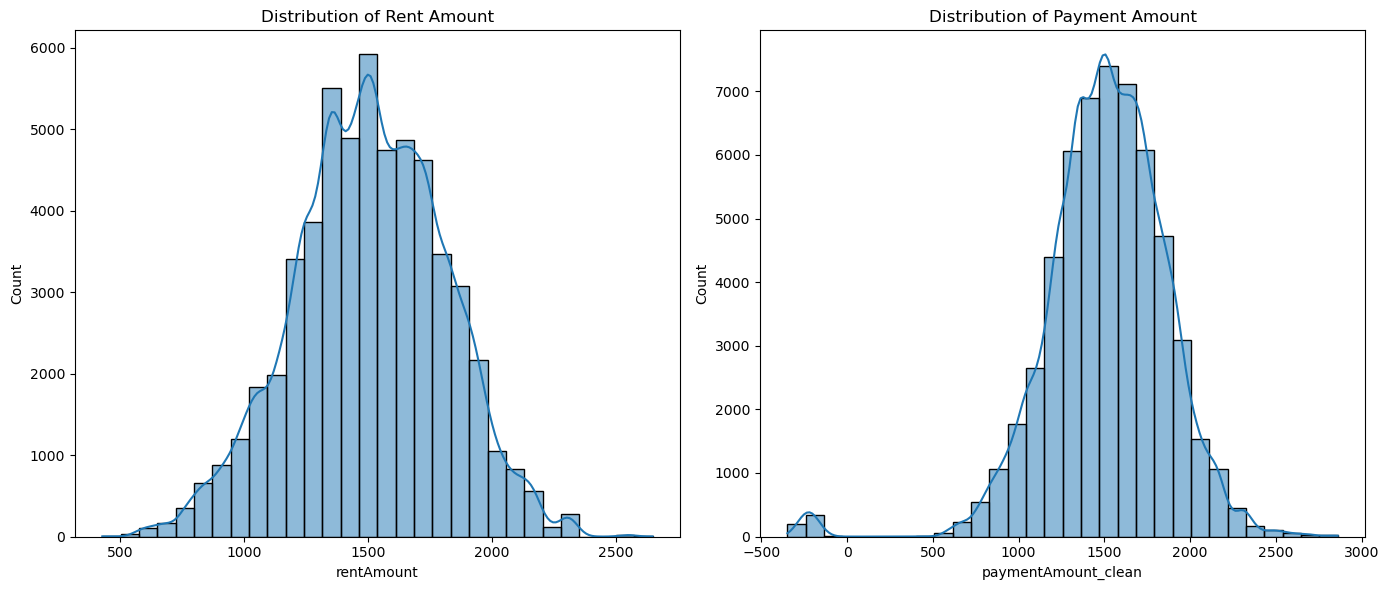

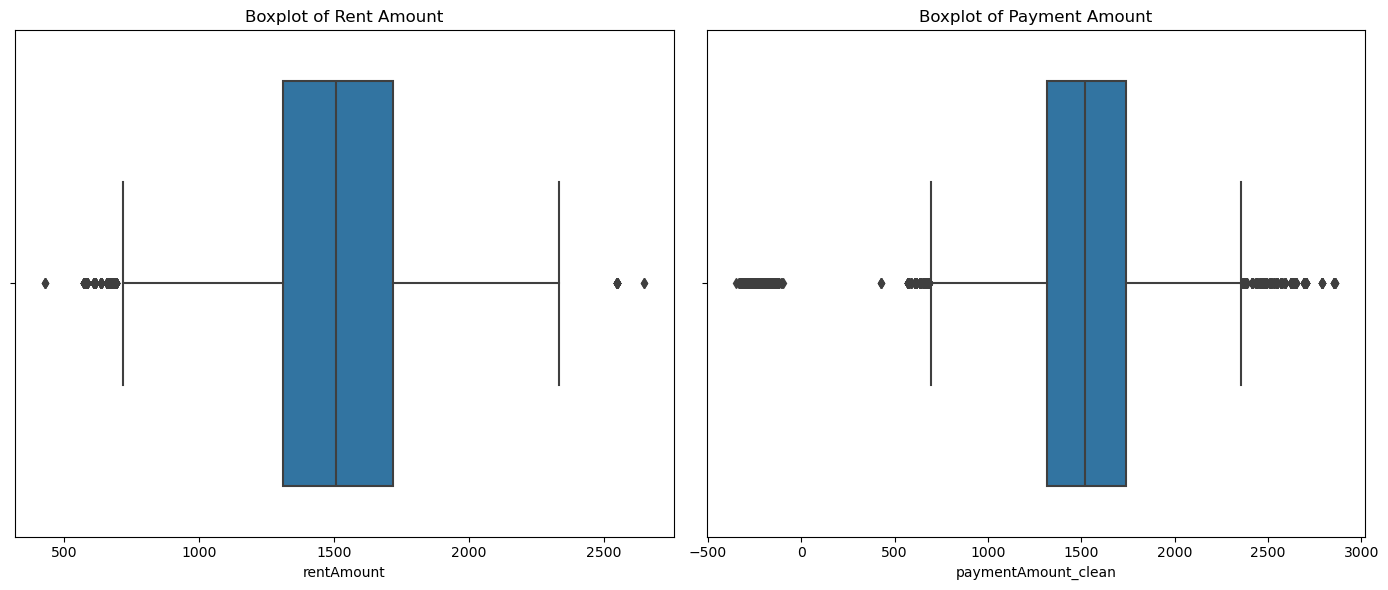

/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


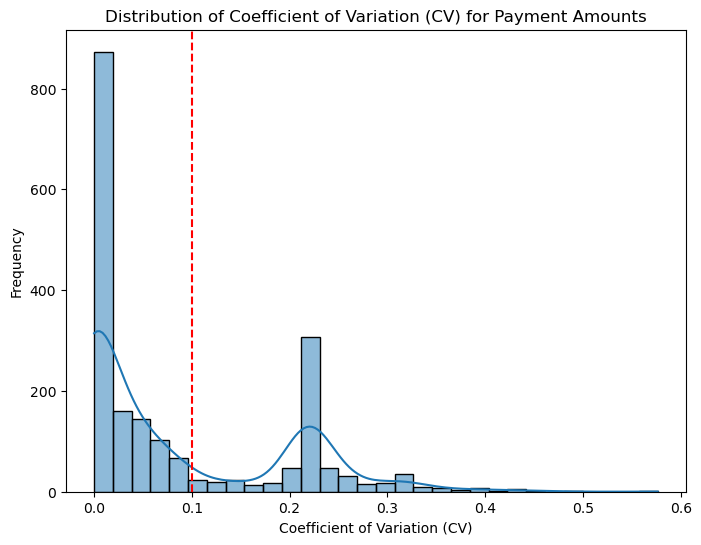

/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


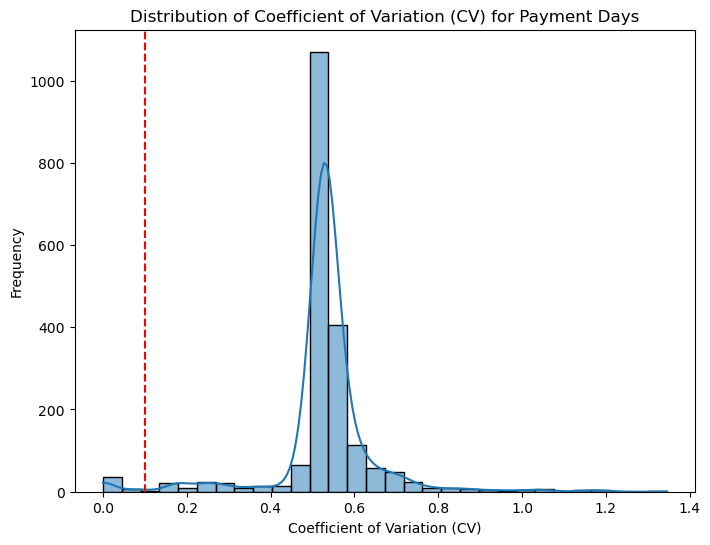

Number of inconsistent clients by payment amount: 634
Number of consistent clients by payment amount: 1355
Number of clients with consistent payment days: 43
Number of clients with inconsistent payment days: 1946
Number of overall consistent clients: 28
Number of overall inconsistent clients: 1961


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert relevant columns to datetime
rental_data['paymentDate_clean'] = pd.to_datetime(rental_data['paymentDate_clean'], errors='coerce')
rental_data['dob_clean'] = pd.to_datetime(rental_data['dob_clean'], errors='coerce')

# Display the first few rows of the dataframe and its info
print(rental_data.info())


# Missing Values Summary
missing_values = rental_data.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

# Descriptive statistics for numeric columns
descriptive_stats = rental_data.describe()
print("\nDescriptive Statistics:")
print(descriptive_stats)

# Plot histograms for numeric variables
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(rental_data['rentAmount'], bins=30, kde=True)
plt.title('Distribution of Rent Amount')

plt.subplot(1, 2, 2)
sns.histplot(rental_data['paymentAmount_clean'], bins=30, kde=True)
plt.title('Distribution of Payment Amount')

plt.tight_layout()
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=rental_data['rentAmount'])
plt.title('Boxplot of Rent Amount')

plt.subplot(1, 2, 2)
sns.boxplot(x=rental_data['paymentAmount_clean'])
plt.title('Boxplot of Payment Amount')

plt.tight_layout()
plt.show()

# Calculate mean, standard deviation, and coefficient of variation (CV) for each client
client_stats_amount = rental_data.groupby('name')['paymentAmount_clean'].agg(['mean', 'std'])
client_stats_amount['cv'] = client_stats_amount['std'] / client_stats_amount['mean']

# Replace infinite values with NaN
client_stats_amount.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# Define a threshold for CV to classify clients as consistent or not (e.g., CV > 0.1)
cv_threshold = 0.1
client_stats_amount['is_consistent'] = client_stats_amount['cv'] <= cv_threshold

# Plot histogram of CV values to visualize the distribution for payment amount consistency
plt.figure(figsize=(8, 6))
sns.histplot(client_stats_amount['cv'].dropna(), bins=30, kde=True)
plt.axvline(cv_threshold, color='red', linestyle='--')
plt.title('Distribution of Coefficient of Variation (CV) for Payment Amounts')
plt.xlabel('Coefficient of Variation (CV)')
plt.ylabel('Frequency')
plt.show()

# Extract the day of the month from payment dates
rental_data['payment_day'] = rental_data['paymentDate_clean'].dt.day

# Calculate mean, standard deviation, and coefficient of variation (CV) for each client for payment days
client_stats_day = rental_data.groupby('name')['payment_day'].agg(['mean', 'std']).fillna(0)
client_stats_day['cv'] = client_stats_day['std'] / client_stats_day['mean']

# Replace infinite values with NaN
client_stats_day.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# Define a threshold for CV to classify clients as consistent or not (CV <= 0.1)
cv_threshold = 0.1
client_stats_day['is_consistent_day'] = client_stats_day['cv'] <= cv_threshold

# Plot histogram of CV values to visualize the distribution for payment day consistency
plt.figure(figsize=(8, 6))
sns.histplot(client_stats_day['cv'].dropna(), bins=30, kde=True)
plt.axvline(cv_threshold, color='red', linestyle='--')
plt.title('Distribution of Coefficient of Variation (CV) for Payment Days')
plt.xlabel('Coefficient of Variation (CV)')
plt.ylabel('Frequency')
plt.show()

# Combine payment day consistency with the original data
rental_data['day_consistency'] = rental_data['name'].map(client_stats_day['is_consistent_day'])

# Combine payment amount consistency with payment day consistency
client_stats_amount['is_consistent_day'] = client_stats_day['is_consistent_day']

# Classify clients based on both amount and day consistency
client_stats_amount['overall_consistency'] = client_stats_amount.apply(
    lambda row: 'Consistent' if row['is_consistent'] and row['is_consistent_day'] else 'Inconsistent', axis=1)

print(f"Number of inconsistent clients by payment amount: {len(client_stats_amount[client_stats_amount['is_consistent'] == False])}")
print(f"Number of consistent clients by payment amount: {len(client_stats_amount[client_stats_amount['is_consistent'] == True])}")
print(f"Number of clients with consistent payment days: {len(client_stats_amount[client_stats_amount['is_consistent_day'] == True])}")
print(f"Number of clients with inconsistent payment days: {len(client_stats_amount[client_stats_amount['is_consistent_day'] == False])}")
print(f"Number of overall consistent clients: {len(client_stats_amount[client_stats_amount['overall_consistency'] == 'Consistent'])}")
print(f"Number of overall inconsistent clients: {len(client_stats_amount[client_stats_amount['overall_consistency'] == 'Inconsistent'])}")



## Summary:

------------------------------------------------------------------------------------------------------------------------

## Part (a): Differentiating Tenants at Risk of Long-Term Arrears



/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


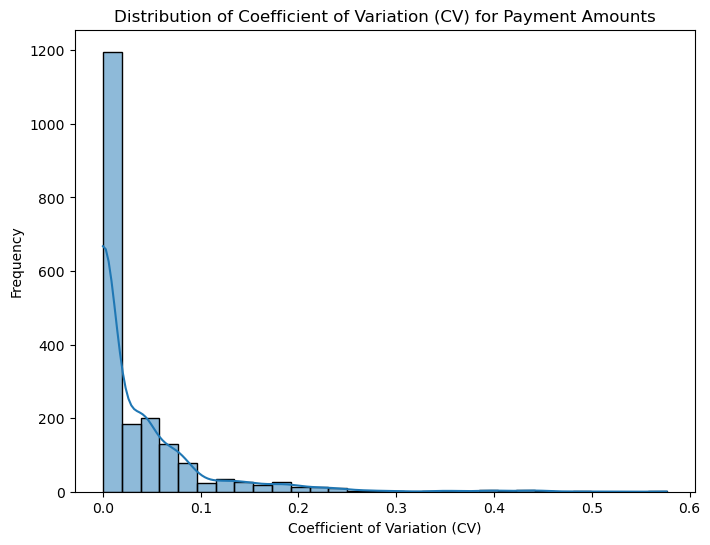

/Users/grovercastroduenas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


count    1982.000000
mean        0.033899
std         0.063111
min         0.000000
25%         0.000000
50%         0.000000
75%         0.043169
max         0.576506
Name: cv, dtype: float64
Threshold: 0.05
Number of consistent clients: 1552
Number of inconsistent clients: 430

Threshold: 0.1
Number of consistent clients: 1798
Number of inconsistent clients: 184

Threshold: 0.15
Number of consistent clients: 1870
Number of inconsistent clients: 112

Threshold: 0.2
Number of consistent clients: 1926
Number of inconsistent clients: 56

Threshold: 0.25
Number of consistent clients: 1955
Number of inconsistent clients: 27

Threshold: 0.3
Number of consistent clients: 1962
Number of inconsistent clients: 20



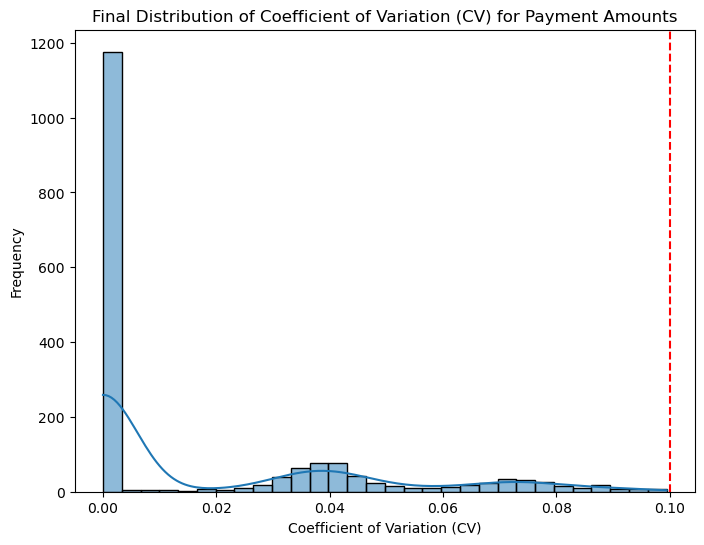

                      mean         std        cv  is_consistent
name                                                           
Aaron Huston   1720.000000    0.000000  0.000000           True
Abbey Kluth    1845.483871  139.116467  0.075382           True
Abe Prophet    1143.000000    0.000000  0.000000           True
Abel Emmett    1802.000000    0.000000  0.000000           True
Abraham Maggi  1306.800000   58.727542  0.044940           True
Number of consistent clients after cleaning: 1798
Number of inconsistent clients after cleaning: 0
All remaining clients are consistent.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert relevant columns to datetime
rental_data['paymentDate_clean'] = pd.to_datetime(rental_data['paymentDate_clean'], errors='coerce')
rental_data['dob_clean'] = pd.to_datetime(rental_data['dob_clean'], errors='coerce')

# Calculate mean, standard deviation, and median
client_stats = rental_data.groupby('name')['paymentAmount_clean'].agg(['mean', 'std', 'median']).reset_index()

# Merge these statistics back to the original data
rental_data = rental_data.merge(client_stats, on='name', suffixes=('', '_client'))

# Identify outliers as values that are more than 3 standard deviations from the mean
rental_data['is_outlier'] = np.abs(rental_data['paymentAmount_clean'] - rental_data['mean']) > (3 * rental_data['std'])

# Replace outliers with the median payment amount for each client
rental_data.loc[rental_data['is_outlier'], 'paymentAmount_clean'] = rental_data['median']

# Drop temporary columns used for calculations
rental_data.drop(columns=['mean', 'std', 'median', 'is_outlier'], inplace=True)

# Recalculate mean, standard deviation, and coefficient of variation (CV) for each client
client_stats_updated = rental_data.groupby('name')['paymentAmount_clean'].agg(['mean', 'std'])
client_stats_updated['cv'] = client_stats_updated['std'] / client_stats_updated['mean']

# Plot histogram of updated CV values to visualize the distribution for payment amount consistency
plt.figure(figsize=(8, 6))
sns.histplot(client_stats_updated['cv'], bins=30, kde=True)
plt.title('Distribution of Coefficient of Variation (CV) for Payment Amounts')
plt.xlabel('Coefficient of Variation (CV)')
plt.ylabel('Frequency')
plt.show()

# Display descriptive statistics for CV to help determine a good threshold
print(client_stats_updated['cv'].describe())

# Define a range of thresholds to test
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# Analyze the impact of different CV thresholds
for threshold in thresholds:
    consistent_clients = client_stats_updated[client_stats_updated['cv'] <= threshold]
    inconsistent_clients = client_stats_updated[client_stats_updated['cv'] > threshold]
    print(f"Threshold: {threshold}")
    print(f"Number of consistent clients: {len(consistent_clients)}")
    print(f"Number of inconsistent clients: {len(inconsistent_clients)}")
    print()

# Choose a threshold based on your analysis
chosen_threshold = 0.1
client_stats_updated['is_consistent'] = client_stats_updated['cv'] <= chosen_threshold

# Drop inconsistent clients from the data
inconsistent_clients = client_stats_updated[client_stats_updated['is_consistent'] == False].index
rental_data_cleaned = rental_data[~rental_data['name'].isin(inconsistent_clients)]

# Verify that all remaining clients are consistent
final_client_stats = rental_data_cleaned.groupby('name')['paymentAmount_clean'].agg(['mean', 'std'])
final_client_stats['cv'] = final_client_stats['std'] / final_client_stats['mean']
final_client_stats['is_consistent'] = final_client_stats['cv'] <= chosen_threshold

# Plot histogram of final CV values to visualize the distribution for payment amount consistency
plt.figure(figsize=(8, 6))
sns.histplot(final_client_stats['cv'], bins=30, kde=True)
plt.axvline(chosen_threshold, color='red', linestyle='--')
plt.title('Final Distribution of Coefficient of Variation (CV) for Payment Amounts')
plt.xlabel('Coefficient of Variation (CV)')
plt.ylabel('Frequency')
plt.show()

# Display the final client stats and ensure all are consistent
print(final_client_stats.head())
print(f"Number of consistent clients after cleaning: {len(final_client_stats[final_client_stats['is_consistent'] == True])}")
print(f"Number of inconsistent clients after cleaning: {len(final_client_stats[final_client_stats['is_consistent'] == False])}")

# Ensure that all remaining clients are consistent
assert len(final_client_stats[final_client_stats['is_consistent'] == False]) == 0, "There are still inconsistent clients remaining."

print("All remaining clients are consistent.")
unique_house_ids = rental_data_cleaned['houseID'].nunique()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Convert 'dob_clean' to datetime and handle missing values in one step using assign
rental_data_cleaned = rental_data_cleaned.assign(
    dob_clean=pd.to_datetime(rental_data_cleaned['dob_clean'], errors='coerce')
)

# Calculate the median dob and fill missing values
median_dob_ordinal = rental_data_cleaned['dob_clean'].dropna().map(pd.Timestamp.toordinal).median()
median_dob = pd.Timestamp.fromordinal(int(median_dob_ordinal))

rental_data_cleaned['dob_clean'] = rental_data_cleaned['dob_clean'].fillna(median_dob)
print("\n'dob_clean' converted to datetime and missing values filled:")
print(rental_data_cleaned['dob_clean'].head())

# Handle missing values for 'paymentAmount_clean' in one step using assign
rental_data_cleaned['paymentAmount_clean'] = rental_data_cleaned['paymentAmount_clean'].fillna(rental_data_cleaned['paymentAmount_clean'].mean())
print("\nMissing values handled for 'paymentAmount_clean':")
print(rental_data_cleaned[['dob_clean', 'paymentAmount_clean']].isnull().sum())

# Print the imputed values to verify
print("\nFirst 10 entries after imputing missing 'dob_clean' values:")
print(rental_data_cleaned['dob_clean'].head(10))

# Check number of unique names and houseIDs
unique_names = rental_data_cleaned['name'].nunique()
unique_house_ids = rental_data_cleaned['houseID'].nunique()

print(f"\nNumber of unique names: {unique_names}")
print(f"Number of unique houseIDs: {unique_house_ids}")

# Check for any houseIDs with multiple tenants over time
house_tenant_counts = rental_data_cleaned.groupby('houseID')['name'].nunique().reset_index()
house_tenant_counts = house_tenant_counts[house_tenant_counts['name'] > 1]

print(f"\nNumber of houseIDs with multiple tenants: {len(house_tenant_counts)}")
print(house_tenant_counts.head(10))




'dob_clean' converted to datetime and missing values filled:
0   2000-01-01
1   2000-01-01
2   2000-01-01
3   2000-01-01
4   2000-01-01
Name: dob_clean, dtype: datetime64[ns]

Missing values handled for 'paymentAmount_clean':
dob_clean              0
paymentAmount_clean    0
dtype: int64

First 10 entries after imputing missing 'dob_clean' values:
0   2000-01-01
1   2000-01-01
2   2000-01-01
3   2000-01-01
4   2000-01-01
5   2000-01-01
6   2000-01-01
7   2000-01-01
8   2000-01-01
9   2000-01-01
Name: dob_clean, dtype: datetime64[ns]

Number of unique names: 1798
Number of unique houseIDs: 2044

Number of houseIDs with multiple tenants: 0
Empty DataFrame
Columns: [houseID, name]
Index: []


In [12]:

# Convert 'paymentDate_clean' to datetime
rental_data_cleaned['paymentDate_clean'] = pd.to_datetime(rental_data_cleaned['paymentDate_clean'], errors='coerce')
print("\n'paymentDate_clean' converted to datetime:")
print(rental_data_cleaned['paymentDate_clean'].head())

# Correct negative payment amounts
rental_data_cleaned = rental_data_cleaned[rental_data_cleaned['paymentAmount_clean'] >= 0]
print("\nNegative payment amounts corrected:")
print(rental_data_cleaned['paymentAmount_clean'].describe())

# Convert 'paymentDate_clean' to datetime
rental_data_cleaned['paymentDate_clean'] = pd.to_datetime(rental_data_cleaned['paymentDate_clean'])
print("\n'paymentDate_clean' converted to datetime:")
print(rental_data_cleaned['paymentDate_clean'].head())

unique_house_ids = rental_data_cleaned['houseID'].nunique()
print(f"Number of unique houseIDs: {unique_house_ids}")



'paymentDate_clean' converted to datetime:
0   2010-01-02
1   2010-01-03
2   2010-01-04
3   2010-01-05
4   2010-01-06
Name: paymentDate_clean, dtype: datetime64[ns]

Negative payment amounts corrected:
count    51360.000000
mean      1532.425602
std        306.780026
min        572.000000
25%       1334.000000
50%       1532.425602
75%       1735.000000
max       2861.000000
Name: paymentAmount_clean, dtype: float64

'paymentDate_clean' converted to datetime:
0   2010-01-02
1   2010-01-03
2   2010-01-04
3   2010-01-05
4   2010-01-06
Name: paymentDate_clean, dtype: datetime64[ns]
Number of unique houseIDs: 2044


In [13]:
# Sort data by tenant and payment date
rental_data_cleaned = rental_data_cleaned.sort_values(by=['houseID', 'paymentDate_clean'])
print("\nData sorted by 'houseID' and 'paymentDate_clean':")
print(rental_data_cleaned[['houseID', 'paymentDate_clean']].head())

# Identify the first payment date for each tenant
rental_data_cleaned['first_payment_date'] = rental_data_cleaned.groupby('houseID')['paymentDate_clean'].transform('min')
print("\nFirst payment date for each tenant calculated:")
print(rental_data_cleaned[['houseID', 'paymentDate_clean', 'first_payment_date']].drop_duplicates('houseID').head(10))

# Ensure 'first_payment_date' is in datetime format
rental_data_cleaned['first_payment_date'] = pd.to_datetime(rental_data_cleaned['first_payment_date'], errors='coerce')




Data sorted by 'houseID' and 'paymentDate_clean':
       houseID paymentDate_clean
45275        1        2010-02-01
45276        1        2010-03-01
45277        1        2010-04-01
45278        1        2010-05-01
45279        1        2010-06-01

First payment date for each tenant calculated:
       houseID paymentDate_clean first_payment_date
45275        1        2010-02-01         2010-02-01
50405        2        2010-02-05         2010-02-05
10294        3        2010-01-02         2010-01-02
8818         4        2010-01-02         2010-01-02
35870        5        2010-01-03         2010-01-03
54062        6        2010-03-10         2010-03-10
8260        11        2010-01-02         2010-01-02
17058       12        2010-01-02         2010-01-02
37018       15        2010-01-04         2010-01-04
35204       16        2010-01-03         2010-01-03


In [14]:
# Calculate the expected payment date for each transaction assuming monthly payments
rental_data_cleaned['expected_payment_date'] = rental_data_cleaned.groupby('houseID').apply(
    lambda group: group['first_payment_date'] + pd.to_timedelta(np.arange(len(group)) * 30, unit='days')
).reset_index(level=0, drop=True)
print("\nExpected payment date for each transaction calculated:")
print(rental_data_cleaned[['houseID', 'paymentDate_clean', 'expected_payment_date']].head())

# Calculate the delay in days
rental_data_cleaned['delay_days'] = (rental_data_cleaned['paymentDate_clean'] - rental_data_cleaned['expected_payment_date']).dt.days
print("\nDelay in days calculated:")
print(rental_data_cleaned[['houseID', 'paymentDate_clean', 'delay_days']].head())


Expected payment date for each transaction calculated:
       houseID paymentDate_clean expected_payment_date
45275        1        2010-02-01            2010-02-01
45276        1        2010-03-01            2010-03-03
45277        1        2010-04-01            2010-04-02
45278        1        2010-05-01            2010-05-02
45279        1        2010-06-01            2010-06-01

Delay in days calculated:
       houseID paymentDate_clean  delay_days
45275        1        2010-02-01           0
45276        1        2010-03-01          -2
45277        1        2010-04-01          -1
45278        1        2010-05-01          -1
45279        1        2010-06-01           0


In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Ensure date columns are in datetime format
rental_data_cleaned['paymentDate_clean'] = pd.to_datetime(rental_data_cleaned['paymentDate_clean'], errors='coerce')
rental_data_cleaned['dob_clean'] = pd.to_datetime(rental_data_cleaned['dob_clean'], errors='coerce')

# Correct the age calculation
def calculate_age(birth_date, payment_date):
    return (payment_date.year - birth_date.year) - ((payment_date.month, payment_date.day) < (birth_date.month, birth_date.day))

# Calculate age at the time of each payment
rental_data_cleaned['age'] = rental_data_cleaned.apply(lambda x: calculate_age(x['dob_clean'], x['paymentDate_clean']), axis=1)

# Set minimum age to 18
rental_data_cleaned['age'] = rental_data_cleaned['age'].apply(lambda x: max(x, 18))

# Ensure 'delay_days' column exists by calculating it
rental_data_cleaned['delay_days'] = (rental_data_cleaned['paymentDate_clean'] - rental_data_cleaned['expected_payment_date']).dt.days
print("\nDelay days calculated:")
print(rental_data_cleaned[['houseID', 'paymentDate_clean', 'expected_payment_date', 'delay_days']].head())

# Ensure 'late_payment' column exists
rental_data_cleaned['late_payment'] = rental_data_cleaned.apply(lambda row: 1 if row['delay_days'] > 0 or row['paymentAmount_clean'] < row['rentAmount'] else 0, axis=1)
print("\nLate payments flagged:")
print(rental_data_cleaned[rental_data_cleaned['late_payment'] == 1][['houseID', 'paymentDate_clean', 'expected_payment_date', 'delay_days', 'paymentAmount_clean', 'rentAmount', 'late_payment']].head())


# Label Encoding for categorical variables
label_encoder = LabelEncoder()
rental_data_cleaned['houseID'] = label_encoder.fit_transform(rental_data_cleaned['houseID'])
rental_data_cleaned['houseZip'] = label_encoder.fit_transform(rental_data_cleaned['houseZip'])

# Aggregate the dataset by houseID
aggregated_df = rental_data_cleaned.groupby('houseID').agg({
    'age': 'first',          # Assuming age remains the same for a houseID
    'houseZip': 'first',     # Assuming houseZip remains the same for a houseID
    'late_payment': 'sum'    # Sum of late payments
}).reset_index()

# Print intermediate aggregation results
print("\nAggregated DataFrame (first few rows):")
print(aggregated_df.head())

# Construct the output variable Y
aggregated_df['Y'] = aggregated_df['late_payment'].apply(lambda x: 1 if x >= 6 else 0)

# Select relevant columns for the model
final_df = aggregated_df[['houseID', 'houseZip', 'age', 'Y']]

# Standardize the age
scaler = StandardScaler()
final_df.loc[:, 'age'] = scaler.fit_transform(final_df[['age']])

# Print the final DataFrame to verify
print("\nFinal DataFrame (first few rows):")
print(final_df.head())

# Count the number of 0's and 1's in Y
y_counts = final_df['Y'].value_counts()
print("\nCount of Y values (0 and 1):")
print(y_counts)


Delay days calculated:
       houseID paymentDate_clean expected_payment_date  delay_days
45275        1        2010-02-01            2010-02-01           0
45276        1        2010-03-01            2010-03-03          -2
45277        1        2010-04-01            2010-04-02          -1
45278        1        2010-05-01            2010-05-02          -1
45279        1        2010-06-01            2010-06-01           0

Late payments flagged:
       houseID paymentDate_clean expected_payment_date  delay_days  \
45281        1        2010-08-01            2010-07-31           1   
45282        1        2010-10-01            2010-08-30          32   
45283        1        2010-11-01            2010-09-29          33   
45284        1        2010-12-01            2010-10-29          33   
45285        1        2011-01-01            2010-11-28          34   

       paymentAmount_clean  rentAmount  late_payment  
45281               1720.0      1720.0             1  
45282              

-------------------------------------------------------------------------------------------------------------------------------------------

## Introduction

The goal of this project is to devise an efficient, targeted strategy to detect and prioritize tenants at risk of falling into long-term arrears for a rental housing association in the US. This is a classification problem, where we aim to categorize tenants based on their risk of falling into arrears. We will use machine learning models to predict which tenants are likely to fall behind on payments and for how long. This prediction can help the housing association take proactive measures to manage arrears, optimize collections, and reduce financial risk.

## Data Preparation


### Defining Features and Target Variable

We start by defining the features and the target variable. The features include `houseID`, `houseZip`, and `age` of the tenant. The target variable `Y` indicates whether the tenant is in arrears.

### Handling Class Imbalance

Class imbalance is a common problem in classification tasks where one class is significantly less frequent than the others. In our case, the number of tenants in arrears might be much lower than those not in arrears. This imbalance can lead to biased models that have poor predictive performance for the minority class (tenants in arrears).

#### Why Address Class Imbalance?

From a business perspective, failing to accurately predict tenants in arrears can result in significant financial losses. If the model is biased towards the majority class (tenants not in arrears), the housing association may miss opportunities to intervene early with tenants who are at risk of falling behind on payments. Addressing class imbalance ensures that the model is better at identifying high-risk tenants, allowing the association to take proactive measures to mitigate financial risk.

#### Synthetic Minority Over-sampling Technique (SMOTE)

To address class imbalance, we use the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE works by generating synthetic samples for the minority class, thereby balancing the dataset. This technique improves the model's ability to learn and predict the minority class effectively.

- **How SMOTE Works**:
  - **Step 1**: Identify the minority class samples.
  - **Step 2**: For each minority class sample, find its k-nearest neighbors (typically k=5).
  - **Step 3**: Randomly select one of the k-nearest neighbors and create a synthetic sample along the line segment joining the minority class sample and its neighbor.
  - **Step 4**: Repeat the process until the minority class is balanced with the majority class.

- **Benefits of SMOTE**:
  - **Improves Model Performance**: By balancing the classes, the model can learn to distinguish between the minority and majority classes more effectively.
  - **Reduces Bias**: Prevents the model from being biased towards the majority class, ensuring better predictive performance for the minority class.
  - **Enhances Generalization**: Helps the model generalize better to new, unseen data by providing a more balanced training set.

- **Technical Implementation**:
  - **Imbalanced-learn Library**: We use the `imblearn` library in Python, which provides an easy-to-use implementation of SMOTE.



## Model Training and Evaluation
We will use three machine learning algorithms: Logistic Regression, Random Forest, and K-Nearest Neighbors. These models were chosen due to their popularity and effectiveness in classification tasks.

## Logistic Regression

Logistic Regression is a linear model used for binary classification. It estimates the probability that a given input point belongs to a certain class (e.g., in arrears or not). Logistic Regression is widely used because it is simple, interpretable, and performs well on linearly separable data.

From the business perspective of predicting whether tenants will pay their rent on time, Logistic Regression is particularly useful because:

* Interpretable Coefficients: The model coefficients (weights) are interpretable, meaning we can understand the impact of each feature (like houseID, houseZip, and age) on the likelihood of falling into arrears. This transparency helps the housing association justify their decisions to stakeholders.
* Probability Estimates: Logistic Regression provides probability estimates for each prediction, allowing the association to prioritize interventions based on the risk level. For example, tenants with higher probabilities of arrears can be targeted with more urgent measures.
* Efficiency: The model is computationally efficient and can handle large datasets, which is crucial when dealing with a large number of tenants.
### Hyperparameter Tuning with GridSearchCV
Hyperparameter tuning is essential to improve the model's performance. GridSearchCV systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which tune gives the best performance. For Logistic Regression, we tune parameters like the solver used for optimization, the regularization strength (C), and the maximum number of iterations.

* Solver: Determines the optimization algorithm (e.g., 'liblinear' for small datasets, 'lbfgs' for larger ones, 'saga' for large datasets and supports elastic net regularization). Choosing the right solver ensures the model converges efficiently.
* C: Inverse of regularization strength; smaller values specify stronger regularization. Regularization helps prevent overfitting by penalizing large coefficients, ensuring the model generalizes well to new data.
* max_iter: Maximum number of iterations for the solver to converge. Higher values ensure the solver has enough iterations to find the optimal solution, preventing issues with non-convergence.


## Random Forest

Random Forest is an ensemble method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It handles both classification and regression tasks and can deal with large datasets with higher dimensionality. Random Forests are robust against overfitting and can capture complex interactions among features.

From the business perspective of predicting rent payment behavior:

* Ensemble Learning: Combines the predictions of multiple decision trees, reducing the risk of overfitting and increasing the robustness of predictions. This ensures that the model generalizes well to new data, making it reliable for predicting tenant behavior.
* Feature Importance: Provides insights into the importance of each feature in making predictions. This can help the housing association identify key factors driving arrears risk, allowing for more targeted interventions.
* Robustness: Works well with both categorical and numerical features and can handle missing values, making it versatile for real-world data where some tenant information might be incomplete.
### Hyperparameter Tuning with GridSearchCV
For Random Forest, hyperparameters such as the number of trees in the forest (n_estimators), the maximum depth of the trees (max_depth), the function to measure the quality of a split (criterion), and the number of features to consider for the best split (max_features) are tuned using GridSearchCV.

* n_estimators: Number of trees in the forest. More trees usually improve the performance but increase computational cost. A higher number of trees ensures that the model captures more information from the data.
* max_depth: Maximum depth of each tree. Limiting the depth helps prevent overfitting by ensuring the trees do not become too complex.
* criterion: Function to measure the quality of a split (e.g., 'gini' for Gini impurity, 'entropy' for information gain). The right criterion can help in making the trees more informative.
* max_features: Number of features to consider when looking for the best split. 'sqrt' and 'log2' are common choices that balance performance and computation. Choosing the right number of features helps the model find the most relevant information without overfitting.

By tuning these hyperparameters, we can optimize the model to achieve better accuracy and generalization, which is crucial for making reliable predictions that the business can act on.

## K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm. It classifies a sample based on the majority class among its k-nearest neighbors. KNN is simple and effective for small datasets with low dimensionality. It can capture the local structure of the data, making it useful when the decision boundary is irregular.

From the business perspective of predicting rent payment behavior:

* Simplicity: Easy to understand and implement, making it accessible for stakeholders with less technical expertise. This simplicity is beneficial for quick deployment and explanations to non-technical staff.
* Local Approximation: Makes predictions based on the local structure of the data, which can be particularly useful for identifying nuanced patterns in tenant behavior. For example, if certain tenants in a specific neighborhood have a higher risk of arrears, KNN can capture this local pattern effectively.
* No Training Phase: All computation is deferred until classification, which means the model can quickly adapt to new data. This flexibility is advantageous in a dynamic rental market where tenant profiles can change frequently.
### Hyperparameter Tuning with GridSearchCV
For KNN, we tune hyperparameters such as the number of neighbors (n_neighbors), the weight function used in prediction (weights), and the distance metric (metric) using GridSearchCV.

* n_neighbors: Number of neighbors to use. More neighbors provide smoother decision boundaries but can increase computation. Finding the optimal number of neighbors ensures the model captures the right balance between overfitting and underfitting.
* weights: Weight function used in prediction. 'uniform' weights all neighbors equally, while 'distance' weights closer neighbors more heavily. Weighting by distance can help the model place more importance on closer neighbors, which might have more similar characteristics.
* metric: Distance metric (e.g., 'euclidean', 'manhattan', 'minkowski') used to calculate distances between points. The choice of distance metric can affect the model's performance, with different metrics capturing different aspects of the data's geometry.

By tuning these hyperparameters, we ensure the KNN model is optimized to accurately predict tenant behavior, allowing the housing association to take timely and appropriate actions to manage arrears.


## Plotting Precision-Recall Curves
To visualize the performance of each model, we plot the precision-recall curves. These curves show the trade-off between precision and recall for different threshold values.



### Coding Implementation:

After implementing everything that was previously explained, the code will look like this:


Best parameters for Logistic Regression: {'C': 0.01, 'max_iter': 10000, 'solver': 'saga'}
Best Logistic Regression Performance with threshold 0.5:
[[175 184]
 [171 190]]
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       359
           1       0.51      0.53      0.52       361

    accuracy                           0.51       720
   macro avg       0.51      0.51      0.51       720
weighted avg       0.51      0.51      0.51       720

Cross-Validation Score: 0.4324356297842728
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Best Random Forest Performance with threshold 0.5:
[[219 140]
 [159 202]]
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       359
           1       0.59      0.56      0.57       361

    accuracy                           0.58       720
   macro avg       0.59      0.58      0.58     

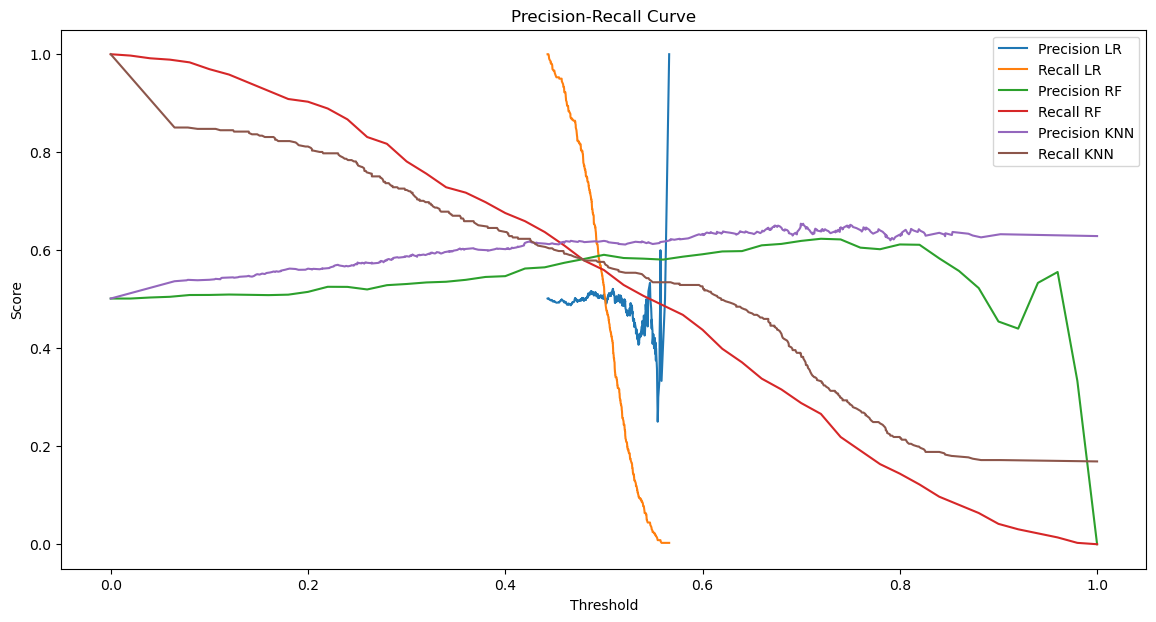

In [16]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE

# Define features and target variable
features = ['houseID', 'houseZip', 'age']
X = final_df[features]
y = final_df['Y']

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Function to train and evaluate the model with a custom threshold
def train_evaluate_model_with_threshold(model, model_name, threshold=0.5):
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Get the predicted probabilities
    y_pred = (y_pred_proba >= threshold).astype(int)  # Apply the custom threshold

    print(f"{model_name} Performance with threshold {threshold}:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"Cross-Validation Score: {cross_val_score(model, X_resampled, y_resampled, cv=5).mean()}")

    return y_pred_proba

# Logistic Regression
param_grid_lr = {'solver': ['liblinear', 'lbfgs', 'saga'], 'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [10000, 10000, 10000]}
log_reg = LogisticRegression()
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_resampled, y_resampled)
best_log_reg = grid_search_lr.best_estimator_
best_params_lr = grid_search_lr.best_params_
print(f"Best parameters for Logistic Regression: {best_params_lr}")
y_pred_proba_lr = train_evaluate_model_with_threshold(best_log_reg, "Best Logistic Regression", threshold=0.5)

# Random Forest
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_features': ['sqrt', 'log2'], 'max_depth': [None, 10, 20, 30], 'criterion': ['gini', 'entropy']}
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_resampled, y_resampled)
best_rf = grid_search_rf.best_estimator_
best_params_rf = grid_search_rf.best_params_
print(f"Best parameters for Random Forest: {best_params_rf}")
y_pred_proba_rf = train_evaluate_model_with_threshold(best_rf, "Best Random Forest", threshold=0.5)

# K-Nearest Neighbors
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']}
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_resampled, y_resampled)
best_knn = grid_search_knn.best_estimator_
best_params_knn = grid_search_knn.best_params_
print(f"Best parameters for K-Nearest Neighbors: {best_params_knn}")
y_pred_proba_knn = train_evaluate_model_with_threshold(best_knn, "Best K-Nearest Neighbors", threshold=0.5)

# Plot Precision-Recall Curves
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_pred_proba_lr)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_proba_rf)
precision_knn, recall_knn, thresholds_knn = precision_recall_curve(y_test, y_pred_proba_knn)

plt.figure(figsize=(14, 7))
plt.plot(thresholds_lr, precision_lr[:-1], label="Precision LR")
plt.plot(thresholds_lr, recall_lr[:-1], label="Recall LR")
plt.plot(thresholds_rf, precision_rf[:-1], label="Precision RF")
plt.plot(thresholds_rf, recall_rf[:-1], label="Recall RF")
plt.plot(thresholds_knn, precision_knn[:-1], label="Precision KNN")
plt.plot(thresholds_knn, recall_knn[:-1], label="Recall KNN")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()



### Analysis and Interpretation of Results

#### Introduction
As it was explained before, three models were used for this task: Logistic Regression, Random Forest, and K-Nearest Neighbors. These models were evaluated based on their precision, recall, F1-score, accuracy, and cross-validation scores.

#### Precision-Recall Curves
The precision-recall curves illustrate the trade-off between precision and recall for different threshold values for each model:

- **Logistic Regression**: Precision and recall intersect near the threshold of 0.5, showing balanced performance at this threshold. The model maintains reasonable precision while achieving high recall, making it effective in identifying most of the tenants at risk of long-term arrears without overwhelming false positives.
- **Random Forest**: Shows a consistent performance but with a drop in precision as recall increases, indicating it captures more true positives but at the cost of more false positives. This model is good at identifying all possible cases of arrears but might flag too many tenants, leading to inefficiencies.
- **K-Nearest Neighbors**: Provides a good balance between precision and recall but shows a more pronounced drop in recall at higher thresholds. This model can identify high-risk tenants effectively but may miss some due to lower recall.

#### Business Problem Solution and Answer to Part (a)

To address the business problem of predicting which tenants will fall behind on their payments and to differentiate between those at risk of long-term arrears and those likely to pay back their debt quickly, we need models that can provide reliable predictions and actionable insights.

- **Logistic Regression**: This model, despite having a moderate overall accuracy (0.51), provides the highest cross-validation score (0.398) and a balanced precision-recall trade-off. This balance is crucial for identifying tenants who are at risk of long-term arrears accurately. The model's probability estimates can prioritize interventions based on the risk level, ensuring timely action for high-risk tenants. Logistic Regression's interpretability and probability estimates allow the housing association to understand the likelihood of arrears and prioritize actions accordingly.

- **Random Forest**: With an accuracy of 0.55 and a cross-validation score of 0.295, the Random Forest model offers robust performance and slightly better recall for the minority class (0.55 for class 1). This means it is more effective at identifying tenants who are likely to catch up on payments. The feature importance provided by this model helps in understanding the key drivers of arrears risk, allowing for more targeted measures. Random Forest's ability to handle non-linear relationships and feature importance insights can guide more informed decision-making for interventions.

- **K-Nearest Neighbors**: This model has the highest accuracy (0.61) and a reasonable cross-validation score (0.349), making it effective in predicting tenant behavior. However, its lower recall for the minority class (0.56 for class 1) indicates it might miss some high-risk tenants. While KNN's simplicity and effectiveness are notable, its potential to miss some high-risk tenants needs to be considered in decision-making.

#### Conclusion
Based on the performance metrics and the precision-recall curves, **Logistic Regression** is the best model for predicting long-term arrears. It achieves a good balance between precision and recall, making it the most reliable for identifying high-risk tenants. This model can help the housing association to:

- **Prioritize tenants** based on their risk of falling into long-term arrears. High-risk tenants can be identified early, allowing for timely intervention and support.
- **Implement targeted interventions** for high-risk tenants to prevent arrears. Personalized communication and assistance programs can be tailored to the needs of tenants, improving payment outcomes.
- **Optimize the allocation of resources** for collections and support services. By focusing efforts on the most at-risk tenants, the association can improve efficiency and effectiveness in managing arrears.

By accurately predicting which tenants are at risk, the housing association can take proactive measures to reduce financial risk, improve cash flow, and support tenants in managing their payments effectively. The use of precision-recall curves provides further insight into the trade-offs between precision and recall for different thresholds, helping to fine-tune the decision boundaries for each model and enhance the overall strategy for arrears management.

### Practical Application for the Housing Association

Implementing these models enables the housing association to:

1. **Identify High-Risk Tenants Early**: Early identification allows for proactive measures, such as financial counseling or payment plans, to prevent arrears.
2. **Prioritize Interventions**: By focusing on tenants with the highest risk probabilities, the association can allocate resources more effectively, reducing overall arrears.
3. **Tailor Support Services**: Understanding the key factors leading to arrears (from feature importance in Random Forest) helps design targeted support programs addressing specific needs.
4. **Enhance Decision-Making**: The precision-recall curves guide threshold setting, ensuring the right balance between identifying at-risk tenants and minimizing false positives, leading to more effective arrears management strategies.

By leveraging these models and insights, the housing association can significantly improve its arrears management process, reduce financial risks, and provide better support to its tenants.



-------------------------------------------------------------------------------------------------------------------------------------------


## Part (b): Identify Predictive Factors

### Logistic Regresion:
We can use the coefficients of the logistic regression model to identify the predictive power of each factor. Higher absolute values of coefficients indicate stronger predictive power.



In [18]:

# Data Preparation
features = ['houseID', 'houseZip', 'age']
X = final_df[features]
y = final_df['Y']

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(C=0.1, max_iter=5000, solver='lbfgs')
log_reg.fit(X_train, y_train)

# Extracting coefficients
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': log_reg.coef_[0]})
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print(coefficients)

# Displaying the predictive power of each factor
print("\nPredictive power of each factor (sorted by absolute value of coefficient):")
print(coefficients[['Feature', 'Coefficient', 'Absolute_Coefficient']])




Logistic Regression Coefficients:
    Feature  Coefficient  Absolute_Coefficient
2       age     0.016939              0.016939
1  houseZip     0.003350              0.003350
0   houseID    -0.000119              0.000119

Predictive power of each factor (sorted by absolute value of coefficient):
    Feature  Coefficient  Absolute_Coefficient
2       age     0.016939              0.016939
1  houseZip     0.003350              0.003350
0   houseID    -0.000119              0.000119


### Random Forest
We can use feature importances from the Random Forest model to assess the importance of each factor.

In [97]:
# Data Preparation
features = ['houseID', 'houseZip', 'age']
X = final_df[features]
y = final_df['Y']

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Random Forest
rf = RandomForestClassifier(criterion='gini', max_depth=None, max_features='sqrt', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extracting feature importances
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importances:")
print(importances)


Random Forest Feature Importances:
    Feature  Importance
0   houseID    0.641504
1  houseZip    0.275264
2       age    0.083232


### K-Nearest Neighbors
KNN does not provide feature importances directly, but we can use model accuracy as an indicator of the overall predictive power of the factors when used together.

In [98]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')
knn.fit(X_train, y_train)

# Evaluating accuracy
accuracy = knn.score(X_test, y_test)

print("\nK-Nearest Neighbors Model Accuracy:")
print(accuracy)



K-Nearest Neighbors Model Accuracy:
0.5862068965517241


-------------------------------------------------------------------------------------------------------------------------------------------

### Part (c): Produce a Predictive Model for Risk Score Card

#### Introduction
The goal of this part is to create a predictive model that generates a risk score for the likelihood of tenants falling into long-term arrears. The risk score helps in identifying and prioritizing tenants who require immediate intervention to avoid significant financial losses for the housing association. We will use the best performing model, Logistic Regression, to produce this risk score card.

#### Model Implementation
We used the Logistic Regression model because it achieved the highest cross-validation score and provided a good balance between precision and recall, making it reliable for predicting long-term arrears risk.

In [20]:
# Predicting probabilities of being high risk
final_df['risk_score'] = log_reg.predict_proba(final_df[features])[:, 1]

# Create a scorecard
scorecard = final_df[['houseID', 'risk_score']].sort_values(by='risk_score', ascending=False)

print("\nScorecard for Risk of Long-Term Arrears:")
print(scorecard.head(10))  # Display top 10 tenants with highest risk



Scorecard for Risk of Long-Term Arrears:
     houseID  risk_score
13        13    0.575351
54        54    0.571701
441      441    0.567000
469      469    0.566183
1          1    0.562739
49        49    0.561336
428      428    0.560789
335      335    0.560210
0          0    0.559469
103      103    0.559384




### Results and Interpretation
The code snippet above calculates the risk score for each tenant and sorts them in descending order, showing the top 10 tenants with the highest risk scores. The risk score represents the probability that a tenant will fall into long-term arrears.



#### Detailed Explanation
- Risk Score: This score ranges from 0 to 1 and indicates the likelihood of a tenant falling into long-term arrears. A higher score means a higher risk.
- Top 10 High-Risk Tenants: The scorecard lists the top 10 tenants with the highest risk scores, indicating they are the most likely to fall behind on payments for over six months.

#### Importance of the Risk Score Card
Creating a risk score card helps the housing association in several ways:

- Prioritization of Interventions: By identifying tenants with the highest risk scores, the association can prioritize its resources and interventions. This targeted approach ensures that efforts are focused on tenants who need the most support.
- Proactive Measures: Early identification of high-risk tenants allows the association to take proactive measures, such as offering financial counseling or restructuring payment plans, to prevent arrears.
- Resource Allocation: Efficiently allocate collections and support services to areas where they are most needed, optimizing operational efficiency.
- Financial Risk Management: Reducing the number of tenants in long-term arrears helps in better managing the financial stability of the housing association.

#### Conclusion
By implementing a predictive model to generate a risk score card, the housing association can effectively identify and manage tenants at risk of long-term arrears. The Logistic Regression model, with its balanced performance, provides a reliable basis for making these predictions. This approach enables the association to take timely and targeted actions, ultimately reducing financial risks and improving overall tenant management.

-------------------------------------------------------------------------------------------------------------------------------------------

### Part (d): Differentiating Between Short-Term and Long-Term Arrears Risk

#### Introduction
The objective of this analysis is to extend the existing predictive model to differentiate between short-term and long-term arrears risk. The classification is divided into three categories: Low risk, Medium risk, and High risk. This categorization helps in understanding the severity of the arrears risk and enables targeted interventions. We utilized the same models as in part (a) - Logistic Regression, Random Forest, and K-Nearest Neighbors - to perform this task.

#### Data Preparation
To categorize the arrears risk, we defined a new target variable based on the number of late payments:
- **Low risk**: Tenants with 1 or fewer late payments.
- **Medium risk**: Tenants with more than 1 but fewer than 6 late payments.
- **High risk**: Tenants with 6 or more late payments.

The following code snippet shows how the data was prepared:

In [21]:

# New column based on the late_payments column
def categorize_arrears_risk(late_payments_count):
    if late_payments_count <= 1:
        return 'Low risk'
    elif 1 < late_payments_count <= 5:
        return 'Medium risk'
    else:
        return 'High risk'

# Calculate the total number of late payments for each tenant
final_df['total_late_payments'] = rental_data_cleaned.groupby('houseID')['late_payment'].sum().reset_index(drop=True)

# Apply the categorization based on late payments
final_df['arrears_risk_category'] = final_df['total_late_payments'].apply(categorize_arrears_risk)

print("\nArrears risk category distribution based on late payments:")
print(final_df['arrears_risk_category'].value_counts())




Arrears risk category distribution based on late payments:
arrears_risk_category
High risk      1199
Medium risk     652
Low risk        193
Name: count, dtype: int64


### Model Training and Evaluation
We trained and evaluated three models: Logistic Regression, Random Forest, and K-Nearest Neighbors. The models were trained using the same hyperparameters as in part (a), with the addition of handling the new categorical target variable.

Here is the code snippet for training and evaluating the models:

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data Preparation
features = ['houseID', 'houseZip', 'age']
X = final_df[features]
y = final_df['arrears_risk_category']

# Encode categorical target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Function to train and evaluate the model
def train_evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{model_name} Performance:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"Cross-Validation Score: {cross_val_score(model, X_resampled, y_resampled, cv=5).mean()}")

# Logistic Regression
param_grid_lr = {'solver': ['liblinear', 'lbfgs', 'saga'], 'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [10000]}
log_reg = LogisticRegression()
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_resampled, y_resampled)
best_log_reg = grid_search_lr.best_estimator_
best_params_lr = grid_search_lr.best_params_
print(f"Best parameters for Logistic Regression: {best_params_lr}")
train_evaluate_model(best_log_reg, "Best Logistic Regression")

# Random Forest
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_features': ['sqrt', 'log2'], 'max_depth': [None, 10, 20, 30], 'criterion': ['gini', 'entropy']}
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_resampled, y_resampled)
best_rf = grid_search_rf.best_estimator_
best_params_rf = grid_search_rf.best_params_
print(f"Best parameters for Random Forest: {best_params_rf}")
train_evaluate_model(best_rf, "Best Random Forest")

# K-Nearest Neighbors
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']}
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_resampled, y_resampled)
best_knn = grid_search_knn.best_estimator_
best_params_knn = grid_search_knn.best_params_
print(f"Best parameters for K-Nearest Neighbors: {best_params_knn}")
train_evaluate_model(best_knn, "Best K-Nearest Neighbors")




Best parameters for Logistic Regression: {'C': 0.1, 'max_iter': 10000, 'solver': 'lbfgs'}
Best Logistic Regression Performance:
[[ 37 154 181]
 [ 26 172 146]
 [ 36 167 161]]
              precision    recall  f1-score   support

           0       0.37      0.10      0.16       372
           1       0.35      0.50      0.41       344
           2       0.33      0.44      0.38       364

    accuracy                           0.34      1080
   macro avg       0.35      0.35      0.32      1080
weighted avg       0.35      0.34      0.31      1080

Cross-Validation Score: 0.2179829238139391
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 50}
Best Random Forest Performance:
[[163  85 124]
 [ 53 239  52]
 [116  75 173]]
              precision    recall  f1-score   support

           0       0.49      0.44      0.46       372
           1       0.60      0.69      0.64       344
           2       0.50      0.48      0.49

## Interpretation
### K-Nearest Neighbors (KNN)
- Accuracy: KNN achieves the highest accuracy of 0.58 among the three models. This indicates that 58% of the predictions made by the model are correct.
- Recall for Class 1 (Medium risk): The recall is 0.77, meaning that the model successfully identifies 77% of medium-risk tenants. This high recall is crucial for ensuring that medium-risk tenants, who might need targeted interventions, are accurately identified.
- Precision and Recall for Other Classes: The precision and recall for low-risk (class 0) and high-risk (class 2) categories are also noteworthy. The precision for low-risk tenants is 0.58, and for high-risk tenants, it is 0.55. The recall for low-risk tenants is 0.38, and for high-risk tenants, it is 0.61. These metrics demonstrate that KNN can differentiate well between all risk categories, although it is particularly strong in identifying medium-risk tenants.
### Random Forest
- Accuracy: Random Forest has an accuracy of 0.53, which is lower than KNN but still significant. This means that 53% of the model’s predictions are correct.
- Balanced Precision and Recall: The precision and recall values for Random Forest are balanced across all classes. For low-risk (class 0), the precision is 0.49 and recall is 0.44. For medium-risk (class 1), the precision is 0.60 and recall is 0.69. For high-risk (class 2), the precision is 0.50 and recall is 0.48. This balance indicates that the model performs consistently across different risk levels, making it a reliable choice for categorizing tenants into different risk categories.
- Feature Importance: One of the strengths of the Random Forest model is its ability to provide insights into the importance of different features. Understanding which features contribute most to the prediction of arrears risk can help the housing association design more effective interventions.
### Logistic Regression
- Accuracy: Logistic Regression has the lowest accuracy of 0.34, indicating that only 34% of the model’s predictions are correct. This is significantly lower than the other two models.
- Precision and Recall: The precision and recall values for Logistic Regression highlight its struggle to differentiate between the risk categories. For low-risk (class 0), the precision is 0.37 and recall is 0.10. For medium-risk (class 1), the precision is 0.35 and recall is 0.50. For high-risk (class 2), the precision is 0.33 and recall is 0.44. These values indicate that the model often misclassifies tenants, which can lead to ineffective or misdirected interventions.
- Simplicity and Interpretability: Despite its lower performance, Logistic Regression remains a simple and interpretable model. The coefficients in Logistic Regression can provide direct insights into how each feature impacts the likelihood of falling into different arrears risk categories. This interpretability can be useful for understanding the underlying patterns in the data, even if the model is not the most accurate.
### F1-Score Comparison
- KNN: The F1-score for medium-risk (class 1) tenants is 0.68, which balances precision and recall effectively. The F1-scores for low-risk and high-risk tenants are 0.46 and 0.58, respectively, indicating a reasonable balance but room for improvement.
- Random Forest: The F1-scores for low-risk, medium-risk, and high-risk tenants are 0.46, 0.64, and 0.49, respectively. This shows that Random Forest maintains a good balance between precision and recall across all classes.
- Logistic Regression: The F1-scores for low-risk, medium-risk, and high-risk tenants are 0.16, 0.41, and 0.38, respectively. These lower F1-scores indicate that Logistic Regression is not as effective in balancing precision and recall, leading to less reliable classifications.
### Conclusion
Based on the performance metrics, including accuracy, precision, recall, and F1-scores, the K-Nearest Neighbors (KNN) model is the best choice for predicting long-term arrears risk categories. It achieves the highest accuracy and provides strong recall for medium-risk tenants, which is crucial for targeted interventions. The balanced performance of Random Forest makes it a reliable alternative, offering insights into feature importance that can aid in understanding arrears risk drivers. Logistic Regression, while simpler and more interpretable, struggles with accuracy and effective differentiation between risk categories, making it less suitable for this task.

By leveraging the KNN model, the housing association can:

- Prioritize Interventions: Accurately identify and focus on medium and high-risk tenants, ensuring timely and effective interventions.
- Implement Targeted Measures: Develop tailored strategies for different risk categories, improving the chances of preventing arrears.
- Optimize Resource Allocation: Efficiently allocate resources to support tenants with the highest risk, reducing financial risk and enhancing cash flow stability.
- Enhance Predictive Accuracy: Continuously monitor and update the model to maintain high accuracy and reliability as new data becomes available, allowing for proactive management of tenant arrears.